# Figuras del capítulo 1 — Generalidades

Generado al dividir `notebooks/figuras_documento.ipynb` por capítulo.
Cada celda es independiente después de la sección 0: se puede correr solo la que cambió.


## 0. Preparación: rutas, estilo y helpers

Las figuras se escriben en `../figures/` de este mismo capítulo.


In [1]:
import json
import logging
import re
import sys
import textwrap
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch, PathPatch, Rectangle
from matplotlib.path import Path as MplPath

NB_DIR = Path.cwd()
CHAPTER_DIR = NB_DIR.parent
PROJECT_DIR = next(d for d in (NB_DIR, *NB_DIR.parents) if (d / "pyproject.toml").exists())
SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from core.config import CLEANED_DIR, PROCESSED_DIR, RAW_DIR, RUNS_DIR, P  # noqa: E402

logging.getLogger("data.annotations").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

FIGURE_DIR = CHAPTER_DIR / "figures"  # capitulos/<capitulo>/figures
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = PROCESSED_DIR
COMPARISON_DIR = RUNS_DIR / "comparacion"

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [2]:
# --- Estilo ------------------------------------------------------------------
SURFACE = "#ffffff"
INK = "#0b0b0b"
INK_2 = "#525252"
MUTED = "#8a8a8a"
GRID = "#e3e3e3"
BASELINE = "#c4c4c4"

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # slots categóricos 1-4
CRITICAL = "#d03b3b"
WARNING = "#eda100"
GOOD = "#1baf7a"
BLUE = "#2a78d6"
BLUE_FADED = "#b7d3f6"
BLUE_INK = "#0d366b"
PANEL = "#f3f3f3"  # relleno de caja de diagrama

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "savefig.edgecolor": SURFACE,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 9,
        "text.color": INK,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 10,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2,
    }
)


def style_value_axis(ax, axis="x"):
    """Rejilla fina sólo en el eje de valor; sin espina de línea base en ese eje."""
    ax.grid(True, axis=axis, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if axis == "x":
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_color(BASELINE)
    else:
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_color(BASELINE)


_K = 0.5523  # constante de control del arco circular en una Bezier cúbica


def _square_path(x0, y0, w, h):
    return MplPath(
        [(x0, y0), (x0 + w, y0), (x0 + w, y0 + h), (x0, y0 + h), (x0, y0)],
        [MplPath.MOVETO] + [MplPath.LINETO] * 3 + [MplPath.CLOSEPOLY],
    )


def _rounded_path(x0, y0, w, h, rx, ry, side="right"):
    """Rectángulo con las dos esquinas de `side` redondeadas: el extremo de dato."""
    rx, ry = min(abs(rx), abs(w)), min(abs(ry), abs(h) / 2)
    if rx <= 0 or ry <= 0 or w == 0 or h == 0:
        return _square_path(x0, y0, w, h)
    x1, y1 = x0 + w, y0 + h

    if side == "right":
        verts = [
            (x0, y0),
            (x1 - rx, y0),
            (x1 - rx + rx * _K, y0),
            (x1, y0 + ry - ry * _K),
            (x1, y0 + ry),
            (x1, y1 - ry),
            (x1, y1 - ry + ry * _K),
            (x1 - rx + rx * _K, y1),
            (x1 - rx, y1),
            (x0, y1),
            (x0, y0),
        ]
    else:  # "top"
        verts = [
            (x0, y0),
            (x1, y0),
            (x1, y1 - ry),
            (x1, y1 - ry + ry * _K),
            (x1 - rx + rx * _K, y1),
            (x1 - rx, y1),
            (x0 + rx, y1),
            (x0 + rx - rx * _K, y1),
            (x0, y1 - ry + ry * _K),
            (x0, y1 - ry),
            (x0, y0),
        ]
    codes = [
        MplPath.MOVETO,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CLOSEPOLY,
    ]
    return MplPath(verts, codes)


def _x_per_y(ax):
    """Unidades de x que se dibujan tan largas como una unidad de y."""
    box = ax.get_position()
    width_in = ax.figure.get_figwidth() * box.width
    height_in = ax.figure.get_figheight() * box.height
    x_range = abs(np.diff(ax.get_xlim())[0])
    y_range = abs(np.diff(ax.get_ylim())[0])
    return (x_range / width_in) / (y_range / height_in)


def barh(ax, ys, widths, color, height=0.62, left=None, radius_frac=0.30, **kw):
    """Barras horizontales con el extremo de dato redondeado. `left` apila."""
    ys = np.atleast_1d(np.asarray(ys, dtype=float))
    widths = np.asarray(widths, dtype=float)
    left = np.zeros_like(widths) if left is None else np.asarray(left, dtype=float)
    ry = height * radius_frac
    rx = ry * _x_per_y(ax)
    for y, w, x0 in zip(ys, widths, left):
        ax.add_patch(
            PathPatch(
                _rounded_path(x0, y - height / 2, w, height, rx, ry, "right"),
                facecolor=color,
                edgecolor="none",
                **kw,
            )
        )
    return ax


def barv(ax, xs, heights, color, width=0.68, radius_frac=0.30, bottom=None, **kw):
    """Barras verticales con la punta redondeada."""
    xs = np.atleast_1d(np.asarray(xs, dtype=float))
    heights = np.asarray(heights, dtype=float)
    bottom = np.zeros_like(heights) if bottom is None else np.asarray(bottom, dtype=float)
    rx = width * radius_frac
    ry = rx / _x_per_y(ax)
    for x, h, y0 in zip(xs, heights, bottom):
        ax.add_patch(
            PathPatch(
                _rounded_path(x - width / 2, y0, width, h, rx, ry, "top"),
                facecolor=color,
                edgecolor="none",
                **kw,
            )
        )
    return ax


# --- Salida ------------------------------------------------------------------
# Dos artefactos por figura: el PNG que `main.tex` incluye hoy y, cuando la figura es
# una serie de datos y no un diagrama, el JSON con esos datos, para poder redibujarla
# en pgfplots sin volver a correr el cuaderno.
DATA_DIR = FIGURE_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)


def _jsonable(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (pd.Series, pd.Index)):
        return value.tolist()
    if isinstance(value, pd.DataFrame):
        return value.to_dict(orient="list")
    raise TypeError(type(value))


def save(fig, name, data=None):
    path = FIGURE_DIR / f"{name}.png"
    fig.savefig(path)
    if data is not None:
        target = DATA_DIR / f"{name}.json"
        target.write_text(json.dumps(data, indent=1, ensure_ascii=False, default=_jsonable))

In [3]:
# --- Helpers de diagrama ------------------------------------------------------


def canvas(width_in=10.0, height_in=5.5):
    fig, ax = plt.subplots(figsize=(width_in, height_in))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100 * height_in / width_in)
    ax.set_aspect("equal")
    ax.axis("off")
    return fig, ax


def wrap_text(text, width=None):
    """Ajusta a `width` respetando los saltos de línea que ya trae el texto."""
    text = str(text)
    if not width:
        return text
    return "\n".join(
        textwrap.fill(line, width) if line.strip() else line for line in text.split("\n")
    )


def _units_per_point(ax):
    """Unidades del lienzo que mide un punto tipográfico (lienzo de 100 de ancho)."""
    return 100.0 / (ax.figure.get_figwidth() * 72.0)


def _stack(ax, blocks):
    """Alturas y separaciones de una pila de bloques de texto, en unidades del lienzo."""
    upt = _units_per_point(ax)
    heights = [(text.count("\n") + 1) * size * 1.34 * upt for text, size, _, _ in blocks]
    gaps = [1.15 * (blocks[i][1] + blocks[i + 1][1]) / 2 * upt for i in range(len(blocks) - 1)]
    return heights, gaps, sum(heights) + sum(gaps)


def _blocks(
    title, body, foot, fs, body_fs, foot_fs, ink, body_ink, foot_ink, weight, wrap, body_wrap
):
    blocks = []
    if title:
        blocks.append((wrap_text(title, wrap), fs, ink, weight))
    if body:
        blocks.append((wrap_text(body, body_wrap or wrap or 30), body_fs, body_ink, "normal"))
    if foot:
        blocks.append((wrap_text(foot, body_wrap or wrap or 30), foot_fs, foot_ink, "normal"))
    return blocks


def node(
    ax,
    cx,
    cy,
    w,
    h=None,
    title="",
    body=None,
    foot=None,
    *,
    fill=PANEL,
    edge=BASELINE,
    ink=INK,
    body_ink=INK_2,
    foot_ink=MUTED,
    lw=1.1,
    fs=9.0,
    body_fs=7.8,
    foot_fs=7.0,
    weight="bold",
    dashed=False,
    wrap=None,
    body_wrap=None,
    radius=1.4,
    pad_pt=9.0,
    zorder=2,
):
    """Caja redondeada centrada en (cx, cy) con hasta tres bloques de texto apilados.

    Con `h=None` la caja se ajusta al texto: es lo que evita las cajas medio vacías y
    los títulos encimados cuando el contenido cambia de largo.
    """
    blocks = _blocks(
        title, body, foot, fs, body_fs, foot_fs, ink, body_ink, foot_ink, weight, wrap, body_wrap
    )
    heights, gaps, total = _stack(ax, blocks)
    if h is None:
        h = total + 2 * pad_pt * _units_per_point(ax)

    ax.add_patch(
        FancyBboxPatch(
            (cx - w / 2, cy - h / 2),
            w,
            h,
            boxstyle=f"round,pad=0,rounding_size={radius}",
            linewidth=lw,
            edgecolor=edge,
            facecolor=fill,
            linestyle=(0, (4, 3)) if dashed else "-",
            zorder=zorder,
            mutation_aspect=1,
        )
    )

    y = cy + total / 2
    for i, (text, size, color, wt) in enumerate(blocks):
        ax.text(
            cx,
            y - heights[i] / 2,
            text,
            ha="center",
            va="center",
            fontsize=size,
            color=color,
            fontweight=wt,
            zorder=zorder + 1,
            linespacing=1.32,
        )
        y -= heights[i] + (gaps[i] if i < len(gaps) else 0)
    return cx, cy, w, h


def node_height(
    ax,
    title,
    body=None,
    foot=None,
    *,
    fs=9.0,
    body_fs=7.8,
    foot_fs=7.0,
    wrap=None,
    body_wrap=None,
    pad_pt=9.0,
):
    blocks = _blocks(
        title, body, foot, fs, body_fs, foot_fs, INK, INK_2, MUTED, "bold", wrap, body_wrap
    )
    return _stack(ax, blocks)[2] + 2 * pad_pt * _units_per_point(ax)


def flow_row(ax, items, cy, *, margin=2.5, gap=2.6, h=None, arrow_color=BLUE, arrows=True, **kw):
    """Fila de cajas que reparte el ancho del lienzo, con flechas entre ellas.

    `items` es una lista de dicts con `title` y, opcionalmente, `body`, `foot` y `kw`.
    El alto es común a toda la fila: el de la caja que más texto lleva.
    """
    n = len(items)
    w = (100 - 2 * margin - (n - 1) * gap) / n
    if h is None:
        h = max(
            node_height(
                ax,
                item["title"],
                item.get("body"),
                item.get("foot"),
                fs=kw.get("fs", 9.0),
                body_fs=kw.get("body_fs", 7.8),
                foot_fs=kw.get("foot_fs", 7.0),
                wrap=item.get("kw", {}).get("wrap", kw.get("wrap")),
                body_wrap=kw.get("body_wrap"),
            )
            for item in items
        )
    boxes = []
    for i, item in enumerate(items):
        cx = margin + w / 2 + i * (w + gap)
        options = dict(kw)
        options.update(item.get("kw", {}))
        boxes.append(
            node(ax, cx, cy, w, h, item["title"], item.get("body"), item.get("foot"), **options)
        )
        if arrows and i:
            arrow(ax, (cx - w / 2 - gap, cy), (cx - w / 2, cy), color=arrow_color, lw=1.3)
    return boxes


def arrow(ax, start, end, *, color=MUTED, lw=1.2, rad=0.0, dashed=False, head="-|>", zorder=1):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        zorder=zorder,
        arrowprops=dict(
            arrowstyle=head,
            color=color,
            linewidth=lw,
            shrinkA=1.5,
            shrinkB=1.5,
            linestyle=(0, (4, 3)) if dashed else "-",
            connectionstyle=f"arc3,rad={rad}",
            mutation_scale=11,
        ),
    )


def elbow(ax, points, *, color=BLUE, lw=1.3):
    """Conector en ángulo recto con punta de flecha en el último tramo."""
    xs, ys = zip(*points)
    ax.plot(xs, ys, color=color, linewidth=lw, solid_capstyle="round", zorder=1)
    arrow(ax, points[-2], points[-1], color=color, lw=lw)


def caption_at(ax, x, y, text, *, fs=7.8, color=INK_2, ha="center", va="center", wrap=None, **kw):
    ax.text(
        x,
        y,
        wrap_text(text, wrap),
        ha=ha,
        va=va,
        fontsize=fs,
        color=color,
        linespacing=1.35,
        **kw,
    )


def chip(ax, cx, cy, text, color=BLUE, *, fs=7.5, pad=1.0, ink=SURFACE):
    """Etiqueta pequeña de fondo lleno: para marcar una salida o un estado."""
    ax.text(
        cx,
        cy,
        text,
        ha="center",
        va="center",
        fontsize=fs,
        color=ink,
        fontweight="bold",
        zorder=5,
        bbox=dict(boxstyle=f"round,pad={pad * 0.3}", facecolor=color, edgecolor="none"),
    )


# --- Glifos de tensor ---------------------------------------------------------
# `node` dibuja una caja con texto: sirve para un módulo, no para el dato que viaja
# entre módulos. Esto es el vocabulario que faltaba -- el espectrograma como plano, los
# tokens contables, la pirámide a escala -- para que un diagrama muestre la forma del
# tensor en vez de describirla por escrito.


def slab(ax, cx, cy, w, h, *, skew=0.16, fill=SURFACE, edge=INK, lw=1.2, zorder=2):
    """Plano en perspectiva: el espectrograma y los mapas de salida."""
    dx = w * skew
    points = [
        (cx - w / 2 + dx, cy - h / 2),
        (cx + w / 2, cy - h / 2),
        (cx + w / 2 - dx, cy + h / 2),
        (cx - w / 2, cy + h / 2),
    ]
    ax.add_patch(
        plt.Polygon(points, closed=True, facecolor=fill, edgecolor=edge, lw=lw, zorder=zorder)
    )
    return points


def token_strip(
    ax, cx, cy, w, h, n, *, vertical=True, fill=SURFACE, edge=INK, lw=0.9, gap=0.30, zorder=3
):
    """Tokens dibujados de a uno: se ven y se cuentan, no se leen en un pie de caja."""
    if vertical:
        cell = h / n
        for k in range(n):
            ax.add_patch(
                Rectangle(
                    (cx - w / 2, cy - h / 2 + k * cell + gap / 2),
                    w,
                    cell - gap,
                    facecolor=fill,
                    edgecolor=edge,
                    lw=lw,
                    zorder=zorder,
                )
            )
    else:
        cell = w / n
        for k in range(n):
            ax.add_patch(
                Rectangle(
                    (cx - w / 2 + k * cell + gap / 2, cy - h / 2),
                    cell - gap,
                    h,
                    facecolor=fill,
                    edgecolor=edge,
                    lw=lw,
                    zorder=zorder,
                )
            )


def feature_pyramid(
    ax, cx, cy, w, h, levels, *, fill=SURFACE, edge=INK, lw=1.1, label_y=None, zorder=3
):
    """Un plano por nivel, con el alto proporcional a su resolución.

    La proporción entre los niveles *es* el dato: dibujarlos todos iguales borra lo
    único que distingue una pirámide multiescala de tres convoluciones en fila.
    """
    tallest = max(rows for rows, _ in levels)
    slot = w / len(levels)
    for k, (rows, cols) in enumerate(levels):
        x = cx - w / 2 + slot * (k + 0.5)
        height = h * (rows / tallest) ** 0.55
        ax.add_patch(
            Rectangle(
                (x - slot * 0.22, cy - height / 2),
                slot * 0.44,
                height,
                facecolor=fill,
                edgecolor=edge,
                lw=lw,
                zorder=zorder,
            )
        )
        y = cy - h / 2 - 1.4 if label_y is None else label_y
        caption_at(ax, x, y, f"{rows}x{cols}", fs=6.0, color=MUTED, va="top")


def patch_grid(ax, cx, cy, w, h, n_cols, n_rows, *, edge=INK, lw=0.9, zorder=3):
    """La rejilla de parches sobre la entrada: el parcheo del AST hecho visible."""
    ax.add_patch(
        Rectangle(
            (cx - w / 2, cy - h / 2),
            w,
            h,
            facecolor=SURFACE,
            edgecolor=edge,
            lw=lw,
            zorder=zorder,
        )
    )
    for i in range(1, n_cols):
        x = cx - w / 2 + w * i / n_cols
        ax.plot([x, x], [cy - h / 2, cy + h / 2], color=edge, lw=lw * 0.7, zorder=zorder + 1)
    for j in range(1, n_rows):
        y = cy - h / 2 + h * j / n_rows
        ax.plot([cx - w / 2, cx + w / 2], [y, y], color=edge, lw=lw * 0.7, zorder=zorder + 1)


def detection_slab(ax, cx, cy, w, h, boxes, *, color=CRITICAL, **kw):
    """El plano de salida con las cajas encima: dónde termina el pipeline."""
    slab(ax, cx, cy, w, h, **kw)
    for bx, by, bw, bh in boxes:
        ax.add_patch(
            Rectangle(
                (cx - w / 2 + (bx - bw / 2) * w, cy - h / 2 + (by - bh / 2) * h),
                bw * w,
                bh * h,
                facecolor="none",
                edgecolor=color,
                lw=1.3,
                zorder=6,
            )
        )


def zoom_arrow(ax, cx, cy, w, h, *, fill=PANEL, edge=MUTED, lw=1.0, zorder=1):
    """Flecha hueca hacia abajo: 'esto de arriba se abre en este panel'."""
    shaft, head = w * 0.42, h * 0.46
    points = [
        (cx - shaft / 2, cy + h / 2),
        (cx + shaft / 2, cy + h / 2),
        (cx + shaft / 2, cy - h / 2 + head),
        (cx + w / 2, cy - h / 2 + head),
        (cx, cy - h / 2),
        (cx - w / 2, cy - h / 2 + head),
        (cx - shaft / 2, cy - h / 2 + head),
    ]
    ax.add_patch(
        plt.Polygon(points, closed=True, facecolor=fill, edgecolor=edge, lw=lw, zorder=zorder)
    )


def detail_panel(ax, cx, cy, w, h, title="", *, edge=BASELINE, lw=1.1, fs=7.6, zorder=0):
    """El recuadro que enmarca un panel de detalle del segundo piso."""
    ax.add_patch(
        FancyBboxPatch(
            (cx - w / 2, cy - h / 2),
            w,
            h,
            boxstyle="round,pad=0,rounding_size=1.6",
            facecolor=SURFACE,
            edgecolor=edge,
            lw=lw,
            zorder=zorder,
        )
    )
    if title:
        caption_at(
            ax,
            cx - w / 2 + 2.0,
            cy + h / 2 - 2.2,
            title,
            fs=fs,
            color=INK,
            ha="left",
            va="top",
            weight="bold",
        )

In [4]:
import soundfile as sf  # noqa: E402
import torch  # noqa: E402
import torchaudio  # noqa: E402

from utils.audio import hz_to_y, mel_spectrogram, y_to_hz  # noqa: E402

MEL = mel_spectrogram(P)


def load_segment(audio_path, start_s=0.0, duration_s=3.0, params=P):
    """Trozo mono de un `.wav`, remuestreado a `params.target_sr`."""
    with sf.SoundFile(str(audio_path)) as handle:
        handle.seek(int(start_s * handle.samplerate))
        frames = handle.read(int(duration_s * handle.samplerate), dtype="float32", always_2d=True)
        waveform = torch.from_numpy(frames.mean(axis=1))
        if handle.samplerate != params.target_sr:
            waveform = torchaudio.functional.resample(waveform, handle.samplerate, params.target_sr)
    return waveform


def log_mel(waveform, params=P):
    return np.log(MEL(waveform).numpy() + params.eps)


def draw_spectrogram(ax, image, duration_s, *, params=P, cmap="magma", n_ticks=5, vrange=(2, 99.5)):
    """Espectrograma log-mel con el eje de frecuencia en el espacio mel normalizado."""
    lo, hi = np.percentile(image, vrange)
    ax.imshow(
        image,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        extent=(0, duration_s, 0, 1),
        interpolation="nearest",
        vmin=lo,
        vmax=hi,
    )
    ticks = np.linspace(0, 1, n_ticks)
    ax.set_yticks(ticks, [f"{y_to_hz(np.array([t]), params)[0] / 1000:.1f}" for t in ticks])
    ax.set_ylabel("frecuencia (kHz, eje mel)")
    ax.set_xlabel("tiempo (s)")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax


def draw_box(
    ax,
    t0,
    t1,
    low_hz,
    high_hz,
    *,
    params=P,
    color=GOOD,
    label=None,
    lw=1.5,
    dashed=False,
    fs=7.5,
    label_below=False,
):
    """Caja tiempo–frecuencia sobre un espectrograma dibujado por `draw_spectrogram`."""
    y0 = float(hz_to_y(np.array([max(low_hz, params.f_min)]), params)[0])
    y1 = float(hz_to_y(np.array([min(high_hz, params.f_max)]), params)[0])
    ax.add_patch(
        FancyBboxPatch(
            (t0, y0),
            t1 - t0,
            y1 - y0,
            boxstyle="round,pad=0,rounding_size=0.012",
            linewidth=lw,
            edgecolor=color,
            facecolor="none",
            linestyle=(0, (4, 2)) if dashed else "-",
            zorder=4,
        )
    )
    if label:
        ax.text(
            t0,
            (y0 - 0.022) if label_below else (y1 + 0.014),
            label,
            color=color,
            fontsize=fs,
            fontweight="bold",
            va="top" if label_below else "bottom",
            ha="left",
            zorder=5,
        )
    return y0, y1

In [5]:
from data.annotations import load_annotations  # noqa: E402
from data.species import (  # noqa: E402
    CALL_TYPES,
    LABEL_SEPARATOR,
    VALID_PAIRS,  # noqa: E402
    Species,
)
from prepare_data import EXCLUDED_LABELS, MIN_PAIR_COUNT, select_experiment  # noqa: E402

annotations = load_annotations()
annotations["pair"] = annotations.species + LABEL_SEPARATOR + annotations.call_type

SPECIES_NAME = {s.name.lower(): s.value.replace("_", " ") for s in Species}
SPECIES_LATIN = {
    "aa": "Aotus azarae",
    "ac": "Ateles chamek",
    "as": "Alouatta sara",
    "cc": "Cebus cuscinus",
    "lw": "Leontocebus weddelli",
    "pt": "Plecturocebus toppini",
    "sb": "Saimiri boliviensis",
    "sm": "Sapajus macrocephalus",
}
CALL_NAME = {
    f"{s.name.lower()}/{code}": label.replace("_", " ")
    for s, codes in CALL_TYPES.items()
    for code, label in codes.items()
}
CALL_NAME["lw/trino"] = "trino (tr, tj, tt y tf fusionados)"


# El mismo filtro que materializa el caché (`prepare_data.select_experiment`).
experiment, LABELS = select_experiment(annotations)
experiment = experiment.copy()
experiment["pair"] = experiment["label"]
CLASSES = LABELS.names


def recording_table():
    """Duración de cada .wav de raw/ y si tiene anotación en cleaned/ (leerlas tarda minutos)."""
    cache = DATA_DIR / "recording_durations.csv"
    if cache.exists():
        return pd.read_csv(cache)
    rows = []
    # .wav y .WAV: el cuaderno del capítulo 4 cuenta las dos, y buscar sólo
    # minúsculas dejaba el total del capítulo 1 una grabación por debajo.
    todos = sorted(set(RAW_DIR.rglob("*.wav")) | set(RAW_DIR.rglob("*.WAV")))
    for wav in todos:
        # Un archivo ilegible se cuenta igual, con duración 0: descartarlo en
        # silencio dejaba el total una grabación por debajo del capítulo 4, que
        # sí lo cuenta y documenta su corrupción.
        try:
            duracion = sf.info(str(wav)).duration
        except Exception:
            duracion = 0.0
        folder = next((p.name for p in wav.parents if "__" in p.name), wav.parent.name)
        cleaned = (CLEANED_DIR / wav.relative_to(RAW_DIR)).with_suffix(".txt")
        rows.append(
            {
                "audio_path": str(wav),
                "species": folder.split("__")[-1].lower(),
                "duration_s": duracion,
                "has_annotation": cleaned.exists(),
            }
        )
    table = pd.DataFrame(rows)
    table.to_csv(cache, index=False)
    return table


recordings = recording_table()

In [6]:
# --- Elegir ejemplos reales de forma determinista -----------------------------


def pick_annotation(pair, *, df=None, rank=0, source=None):
    """Anotación de `pair` cuya duración es la `rank`-ésima más cercana a la mediana."""
    table = annotations if df is None else df
    rows = table[table.pair == pair]
    if source is not None:
        rows = rows[rows.audio_path.str.contains(source)]
    if rows.empty:
        raise LookupError(f"sin anotaciones para {pair}")
    order = (rows.duration_s - rows.duration_s.median()).abs().sort_values().index
    return rows.loc[order[min(rank, len(order) - 1)]]


def busiest_segment(pair, window_s=6.0, *, df=None, n_events=6):
    """Ventana de `window_s` con un número de eventos de `pair` cercano a `n_events`."""
    table = annotations if df is None else df
    rows = table[table.pair == pair]
    best = []
    for audio_path, group in rows.groupby("audio_path"):
        for start in group.begin_time_s.to_numpy():
            inside = group[(group.begin_time_s >= start) & (group.end_time_s <= start + window_s)]
            if len(inside):
                best.append(
                    (
                        abs(len(inside) - n_events),
                        -float(inside.duration_s.sum()),
                        audio_path,
                        start,
                    )
                )
    best.sort()
    _, _, audio_path, start = best[0]
    inside = table[
        (table.audio_path == audio_path)
        & (table.end_time_s > start)
        & (table.begin_time_s < start + window_s)
    ]
    return audio_path, float(start), inside


def segment_around(row, pad_ratio=0.9, min_pad_s=0.25, params=P):
    """Inicio y duración de un trozo centrado en la anotación `row`."""
    pad = max(row.duration_s * pad_ratio, min_pad_s)
    start = max(row.begin_time_s - pad, 0.0)
    return start, float(row.duration_s + 2 * pad)

## 1. Generalidades

Cifras por especie del material recibido (`tabla_material.tex`). El árbol de problemas
y el diagrama de CRISP-DM se dibujan en TikZ dentro del `.tex`; sus celdas se eliminaron.


In [7]:
# Material recibido por especie: grabaciones, horas, cuántas traen anotación y
# cuántos minutos de evento se anotaron. Una sola tabla para todo el capítulo:
# antes había dos, con cifras que no cuadraban entre sí ni con el capítulo 4.
per_species = recordings.groupby("species").agg(
    files=("audio_path", "count"),
    recorded_h=("duration_s", lambda s: s.sum() / 3600),
)
per_species["annotated_files"] = (
    recordings[recordings.has_annotation].groupby("species").audio_path.count()
    .reindex(per_species.index).fillna(0).astype(int)
)
per_species["event_min"] = (
    (annotations.groupby("species").duration_s.sum() / 60).reindex(per_species.index).fillna(0)
)
per_species["share"] = per_species.event_min / (per_species.recorded_h * 60)
per_species = per_species.sort_values("recorded_h", ascending=False)

NOMBRE_ES = {
    "as": "Mono aullador", "sm": "Capuchino de cabeza grande",
    "ac": "Mono araña peruano", "lw": "Tamarino de Weddell",
    "pt": "Tití de Toppin", "sb": "Mono ardilla boliviano",
    "aa": "Mono nocturno", "cc": "Capuchino de cabeza chata",
}


def coma(x, d=0):
    return f"{x:,.{d}f}".replace(",", "~").replace(".", ",").replace("~", r"\,")


filas = [
    f"        {NOMBRE_ES[s]} ({s.upper()}) & {coma(r.files)} & {coma(r.recorded_h, 2)} & "
    f"{coma(r.annotated_files)} & {coma(r.event_min, 1)} & {coma(100 * r.share, 1)} \\\\"
    for s, r in per_species.iterrows()
]
tot_files = per_species.files.sum()
tot_h = per_species.recorded_h.sum()
tot_ann = per_species.annotated_files.sum()
tot_min = per_species.event_min.sum()
filas.append(r"        \midrule")
filas.append(
    rf"        \textbf{{Total}} & \textbf{{{coma(tot_files)}}} & \textbf{{{coma(tot_h, 2)}}} & "
    rf"\textbf{{{coma(tot_ann)}}} & \textbf{{{coma(tot_min, 1)}}} & "
    rf"\textbf{{{coma(100 * tot_min / (tot_h * 60), 1)}}}"
)
# Sin salto final y sin cerrar la última fila: el \\ lo pone el .tex (si no,
# el salto abre una fila vacía y \bottomrule da "Misplaced \noalign").
(FIGURE_DIR / "tabla_material.tex").write_text("\n".join(filas))

# Las cifras que el cuerpo cita, con prefijo g para no chocar con las de los
# capítulos 4 y 5, que se cargan en el mismo preámbulo.
VALORES = {
    "g_recordings": coma(tot_files),
    "g_hours": coma(tot_h, 2),
    "g_annotated": coma(tot_ann),
    "g_annotated_hours": coma(
        recordings[recordings.has_annotation].duration_s.sum() / 3600, 2),
    "g_event_minutes": coma(tot_min, 1),
    "g_event_share": coma(100 * tot_min / (tot_h * 60), 1),
}


def macro(clave):
    return "".join(p.capitalize() if i else p for i, p in enumerate(clave.split("_")))


otros = set()
for cap in ("04_oe1_curacion", "05_oe2_detector"):
    ruta = CHAPTER_DIR.parent / cap / "figures/valores.tex"
    if ruta.exists():
        otros |= set(re.findall(r"\\newcommand\{\\([A-Za-z]+)\}", ruta.read_text()))
choques = sorted(otros & {macro(k) for k in VALORES})
assert not choques, f"macros repetidas con otros capítulos: {choques}"

(FIGURE_DIR / "valores.tex").write_text(
    "".join(f"\\newcommand{{\\{macro(k)}}}{{{v}}}\n" for k, v in sorted(VALORES.items()))
)
print("\n".join(filas))
print(VALORES)


        Mono aullador (AS) & 808 & 7,57 & 778 & 324,6 & 71,5 \\
        Capuchino de cabeza grande (SM) & 659 & 6,13 & 582 & 16,6 & 4,5 \\
        Mono araña peruano (AC) & 561 & 6,07 & 384 & 30,7 & 8,4 \\
        Tamarino de Weddell (LW) & 530 & 5,28 & 410 & 47,5 & 15,0 \\
        Tití de Toppin (PT) & 375 & 3,35 & 320 & 94,3 & 47,0 \\
        Mono ardilla boliviano (SB) & 290 & 3,08 & 256 & 12,2 & 6,6 \\
        Mono nocturno (AA) & 117 & 1,10 & 82 & 2,5 & 3,8 \\
        Capuchino de cabeza chata (CC) & 16 & 0,11 & 7 & 0,1 & 1,2 \\
        \midrule
        \textbf{Total} & \textbf{3\,356} & \textbf{32,69} & \textbf{2\,819} & \textbf{528,5} & \textbf{26,9}
{'g_recordings': '3\\,356', 'g_hours': '32,69', 'g_annotated': '2\\,819', 'g_annotated_hours': '26,34', 'g_event_minutes': '528,5', 'g_event_share': '26,9'}


## 2. Qué es una anotación, qué formas tiene la salida y cómo se puntúa

`annotation_example`, `output_forms` e `iou_criterion`. Antes vivían en el cuaderno
del capítulo 2, que no las usa.


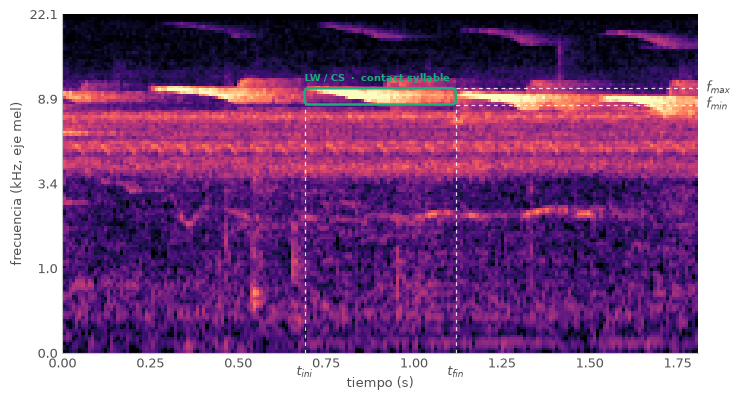

In [8]:
row = pick_annotation("lw/cs")
start_s, duration_s = segment_around(row, pad_ratio=1.6, min_pad_s=0.5)
waveform = load_segment(row.audio_path, start_s, duration_s)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
draw_spectrogram(ax, log_mel(waveform), duration_s)

t0, t1 = row.begin_time_s - start_s, row.end_time_s - start_s
y0, y1 = draw_box(
    ax,
    t0,
    t1,
    row.low_freq_hz,
    row.high_freq_hz,
    color=GOOD,
    label=f"{row.species.upper()} / {row.call_type.upper()}  ·  {CALL_NAME.get(row.pair, '')}",
    lw=1.8,
)

guide = dict(color=SURFACE, linewidth=0.9, linestyle=(0, (3, 3)), zorder=3, alpha=0.85)
for t in (t0, t1):
    ax.plot([t, t], [0, y0], **guide)
for y in (y0, y1):
    ax.plot([t1, duration_s], [y, y], **guide)

for t, name in ((t0, r"$t_{ini}$"), (t1, r"$t_{fin}$")):
    ax.annotate(
        name,
        xy=(t, 0),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        color=INK_2,
        fontsize=9,
    )
for y, name in ((y0, r"$f_{min}$"), (y1, r"$f_{max}$")):
    ax.annotate(
        name,
        xy=(1, y),
        xycoords=("axes fraction", "data"),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        color=INK_2,
        fontsize=9,
        annotation_clip=False,
    )

save(fig, "annotation_example")
plt.show()

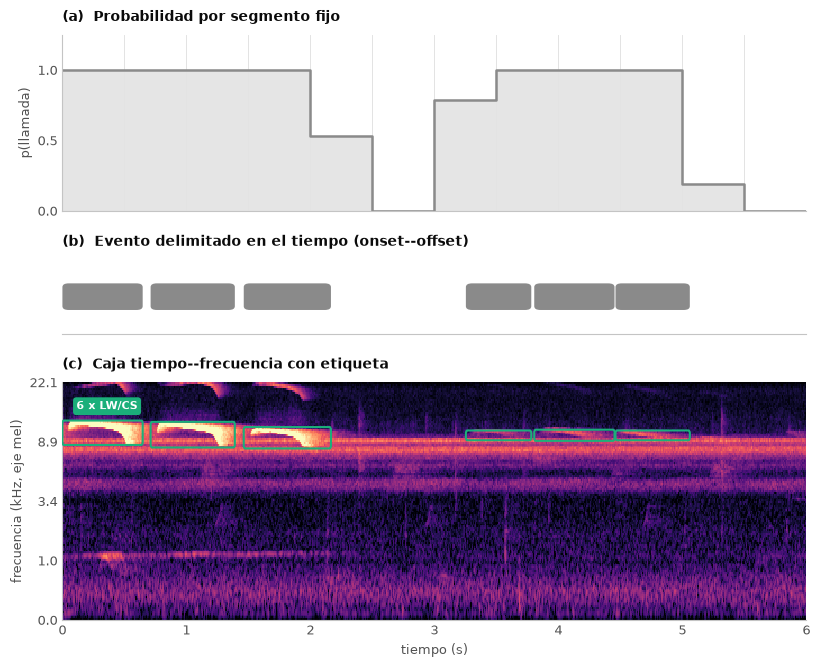

In [9]:
TARGET = "lw/cs"
duration_s = 6.0
audio_path, start_s, inside = busiest_segment(
    TARGET, window_s=duration_s, df=experiment, n_events=6
)
inside = inside[inside.pair == TARGET]
waveform = load_segment(audio_path, start_s, duration_s)
image = log_mel(waveform)
events = [
    (r.begin_time_s - start_s, r.end_time_s - start_s, r.low_freq_hz, r.high_freq_hz, r.pair)
    for r in inside.itertuples()
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9.6, 7.6),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 0.42, 1.35], "hspace": 0.30},
)

ax = axes[0]
seg = 0.5
edges = np.arange(0, duration_s + seg, seg)
covered = np.array(
    [
        sum(max(0, min(e, hi) - max(s, lo)) for s, e, *_ in events) / seg
        for lo, hi in zip(edges[:-1], edges[1:])
    ]
)
probability = np.clip(covered * 1.6, 0, 1)
ax.step(
    np.repeat(edges, 2)[1:-1],
    np.repeat(probability, 2),
    color=MUTED,
    linewidth=1.8,
    where="pre",
)
ax.fill_between(
    np.repeat(edges, 2)[1:-1], np.repeat(probability, 2), step="pre", color=GRID, alpha=0.9
)
for edge in edges:
    ax.axvline(edge, color=GRID, linewidth=0.7, zorder=0)
ax.set_ylim(0, 1.25)
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylabel("p(llamada)")
ax.set_title("(a)  Probabilidad por segmento fijo", fontsize=10, pad=10)

ax = axes[1]
for t0, t1, *_ in events:
    ax.add_patch(
        FancyBboxPatch(
            (t0, 0.32),
            t1 - t0,
            0.36,
            boxstyle="round,pad=0,rounding_size=0.05",
            facecolor=MUTED,
            edgecolor="none",
        )
    )
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title("(b)  Evento delimitado en el tiempo (onset--offset)", fontsize=10, pad=10)
for side in ("left", "top", "right"):
    ax.spines[side].set_visible(False)

ax = axes[2]
draw_spectrogram(ax, image, duration_s)
for i, (t0, t1, low, high, pair) in enumerate(events):
    draw_box(ax, t0, t1, low, high, color=GOOD, lw=1.5)
chip(ax, duration_s * 0.06, 0.90, f"{len(events)} x {TARGET.upper()}", GOOD, fs=8)
ax.set_title("(c)  Caja tiempo--frecuencia con etiqueta", fontsize=10, pad=10)

save(fig, "output_forms")
plt.show()

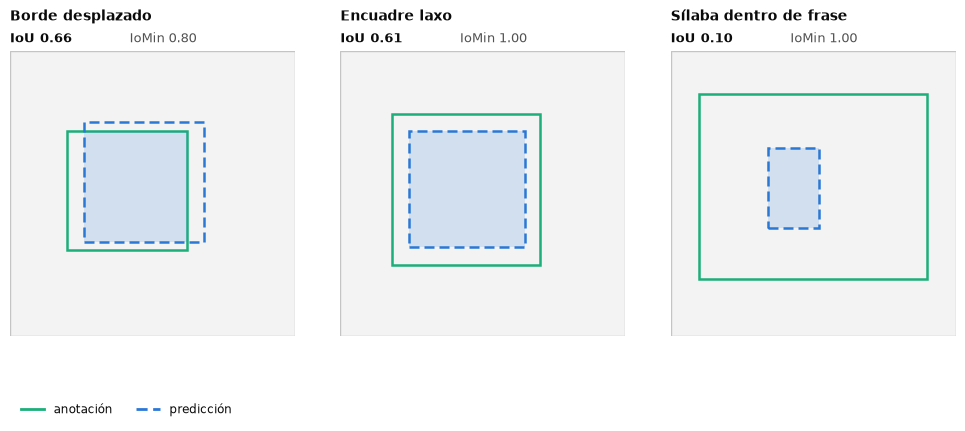

In [10]:
from torchvision.ops import (
    box_area,  # noqa: E402
    box_iou,  # noqa: E402
)


def _min_area_iou(boxes_xyxy):
    """Intersección sobre el área de la caja chica (IoMin), como en `utils.boxes.suppress_nested`."""
    top_left = torch.max(boxes_xyxy[:, None, :2], boxes_xyxy[None, :, :2])
    bottom_right = torch.min(boxes_xyxy[:, None, 2:], boxes_xyxy[None, :, 2:])
    intersection = (bottom_right - top_left).clamp(min=0).prod(-1)
    area = box_area(boxes_xyxy)
    return intersection / torch.min(area[:, None], area[None]).clamp(min=1e-6)

CASES = [
    (
        "Borde desplazado",
        (0.20, 0.30, 0.62, 0.72),
        (0.26, 0.33, 0.68, 0.75),
        "el anotador y el modelo no cierran el evento en el mismo sitio",
    ),
    (
        "Encuadre laxo",
        (0.18, 0.25, 0.70, 0.78),
        (0.24, 0.31, 0.65, 0.72),
        "misma detección, caja más floja: castiga IoU 0,75 y no IoU 0,25",
    ),
    (
        "Sílaba dentro de frase",
        (0.10, 0.20, 0.90, 0.85),
        (0.34, 0.38, 0.52, 0.66),
        "IoU la separa; IoMin la delata como anidada",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.6), gridspec_kw={"wspace": 0.16})
for ax, (name, a, b, _note) in zip(axes, CASES):
    box_a = torch.tensor([a], dtype=torch.float32)
    box_b = torch.tensor([b], dtype=torch.float32)
    iou = float(box_iou(box_a, box_b)[0, 0])
    iomin = float(_min_area_iou(torch.cat([box_a, box_b]))[0, 1])

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.add_patch(Rectangle((0, 0), 1, 1, facecolor=PANEL, edgecolor=BASELINE, linewidth=1.0))
    ax.add_patch(
        Rectangle(
            (a[0], a[1]), a[2] - a[0], a[3] - a[1], facecolor="none", edgecolor=GOOD, linewidth=1.8
        )
    )
    ax.add_patch(
        Rectangle(
            (b[0], b[1]),
            b[2] - b[0],
            b[3] - b[1],
            facecolor="none",
            edgecolor=BLUE,
            linewidth=1.8,
            linestyle=(0, (4, 2)),
        )
    )
    lo = (max(a[0], b[0]), max(a[1], b[1]))
    hi = (min(a[2], b[2]), min(a[3], b[3]))
    ax.add_patch(
        Rectangle(lo, hi[0] - lo[0], hi[1] - lo[1], facecolor=BLUE, alpha=0.16, edgecolor="none")
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.set_title(name, fontsize=10, pad=22)
    ax.annotate(
        f"IoU {iou:.2f}",
        xy=(0, 1),
        xytext=(0, 4),
        xycoords="axes fraction",
        textcoords="offset points",
        fontsize=9.5,
        color=INK,
        fontweight="bold",
        va="bottom",
    )
    ax.annotate(
        f"IoMin {iomin:.2f}",
        xy=(0.42, 1),
        xytext=(0, 4),
        xycoords="axes fraction",
        textcoords="offset points",
        fontsize=9.5,
        color=INK_2,
        va="bottom",
    )

handles = [
    plt.Line2D([], [], color=GOOD, linewidth=2, label="anotación"),
    plt.Line2D([], [], color=BLUE, linewidth=2, linestyle=(0, (4, 2)), label="predicción"),
]
axes[0].legend(handles=handles, loc="lower left", bbox_to_anchor=(0, -0.32), ncol=2)
save(fig, "iou_criterion")
plt.show()